In [1]:
import datetime
import os
import pathlib
import sys
import urllib.request

import dateutil.relativedelta
import IPython.display
import matplotlib.pyplot
import numpy
import polars
import sunburst

INTRODUCTION_DIR = pathlib.Path.cwd() / "01_introduction"

os.environ["INTRODUCTION_DIR"] = str(INTRODUCTION_DIR)
if str(INTRODUCTION_DIR) not in sys.path:
    sys.path.append(str(INTRODUCTION_DIR))

from utils import list_code

# Introduction
## Download HTTP transfer size timeseries from HTTP archive and store as CSV

We provide `01_introduction/input_datasets/http_archive_bytes_total.csv` in our dataset. The code below documents how we gathered this data in case you want to generate your own, more updated time series.

In [2]:
with urllib.request.urlopen(
    "https://cdn.httparchive.org/v1/static/reports/bytesTotal.json"
) as json:
    df = polars.read_json(
        json,
    ).with_columns(
        polars.from_epoch(polars.col("timestamp").cast(polars.Float64) / 1000).dt.date(),
        polars.col("p10").cast(polars.Float64),
        polars.col("p25").cast(polars.Float64),
        polars.col("p50").cast(polars.Float64),
        polars.col("p75").cast(polars.Float64),
        polars.col("p90").cast(polars.Float64),
    )
df.write_csv(INTRODUCTION_DIR / "input_datasets" / "http_archive_bytes_total.csv")

## History of HTTP transfer sizes of web resources

The following code generates Figure 1 of our paper.

### [HTTP Transfer Size](01_introduction/plots/http-archive-bytes-total.pdf)

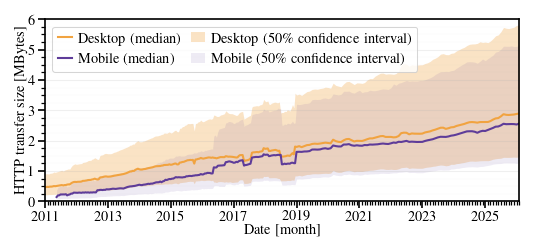

In [3]:
SLIDE_VERSION = False                   # Set to True for styling for slide set
#SLIDE_VERSION = True
# END_DATE = datetime.date(2025, 7, 1)
END_DATE = datetime.date(2026, 2, 1)    # Fixed for reproducability, increase this value for newer timeseries

matplotlib.pyplot.clf()
matplotlib.pyplot.close("all")

if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullslide.mplstyle")
    matplotlib.use("pgf")
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0], matplotlib.rcParams["figure.figsize"][1]
else:
    #matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_acm.mplstyle")
    # matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth.mplstyle")
    #matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth_acmsmall.mplstyle")
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_ieeetran.mplstyle")
    matplotlib.use("inline")
    #matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0] * 1.18, matplotlib.rcParams["figure.figsize"][1] * 1.5
    #matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0] * 1.17, matplotlib.rcParams["figure.figsize"][1] * 5 / 8
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0], matplotlib.rcParams["figure.figsize"][1] * 5 / 8

COLORS={
    "Desktop": "C0",
    "Mobile": "C1",
}
ALPHAS={
    "Desktop": 0.3,
    "Mobile": 0.1,
}

matplotlib.pyplot.rc('axes', prop_cycle=matplotlib.pyplot.cycler(color=["#f1a340", "#5e3c99"]))
lf = polars.scan_csv(
    INTRODUCTION_DIR / "input_datasets" / "http_archive_bytes_total.csv"
).with_columns(
    polars.col("client").str.to_titlecase(),
    polars.col("timestamp").str.to_date(),
).group_by(["client", "timestamp"]).agg(
    polars.col("p25").sum(),
    polars.col("p50").sum(),
    polars.col("p75").sum(),
)

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

for client in ["Desktop", "Mobile"]:
    df = lf.filter(
        polars.col("client") == client
    ).sort("timestamp").interpolate().collect()
    ax.plot(df["timestamp"], df["p50"], color=COLORS[client], label=f"{client} (median)")
    ax.fill_between(
        df["timestamp"],
        df["p25"],
        df["p75"],
        color=COLORS[client],
        alpha=ALPHAS[client],
        linewidth=0,
        label=fr"{client} (50\% confidence interval)"
    )
    
ax.set_xlabel("Date [month]")
ax.set_xlim((df["timestamp"].min(), END_DATE))
ax.set_xticks(
    polars.date_range(
        df["timestamp"].min() + dateutil.relativedelta.relativedelta(month=1, day=1),
        END_DATE,
        "2y",
        eager=True,
    )
)
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(matplotlib.dates.MonthLocator())

ax.set_ylabel("HTTP transfer size [MBytes]")
ax.set_ylim((0, 5.5 * 1024 + 128))
ax.set_yticks(numpy.arange(0, 6 * 1024 + 1, 1024))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(n=4))

matplotlib.pyplot.grid(axis="y", alpha=0.2, which="minor", linewidth=0.1)
matplotlib.pyplot.grid(axis="y", alpha=0.2, which="major", linewidth=0.5)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"{y // 1024}"))

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    ncol=2,
    handles=handles[::2] + handles[1::2],
    labels=labels[::2] + labels[1::2],
    loc="upper left"
)

if not (INTRODUCTION_DIR / "plots").exists():
    (INTRODUCTION_DIR / "plots").mkdir()

filepath = INTRODUCTION_DIR / "plots" / "http-archive-bytes-total.pdf"
IPython.display.display(IPython.display.Markdown(f"### [HTTP Transfer Size]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()
matplotlib.pyplot.close(fig)

## History of JSON request ratio on desktop

We fetched this data using the HTTP Archive BigQuery database.
From the [HTTP Archive FAQ](https://web.archive.org/web/20240921023218/https://httparchive.org/faq#how-do-i-use-bigquery-to-write-custom-queries-over-the-data) in September, 2024:

> How do I use BigQuery to write custom queries over the data?
> 
> The HTTP Archive dataset is available on BigQuery. Be aware that as a consequence of collecting so much metadata from millions of websites each month, the dataset is extremely large—multiple petabytes. Care must be taken to set up [cost controls](https://cloud.google.com/bigquery/docs/custom-quotas) to avoid unexpected bills. Also see our guide to [minimizing query costs](https://har.fyi/guides/minimizing-costs/) for tips on staying under the 1 TB per month free quota.
> 
> Check out [Getting Started Accessing the HTTP Archive with BigQuery](https://github.com/HTTPArchive/httparchive.org/blob/main/docs/gettingstarted_bigquery.md) [now moved to, a guide for first-time users written by [Paul Calvano](https://twitter.com/paulcalvano).
> 
> For a guided walkthrough of the project, watch this in-depth [30 minute video](https://www.youtube.com/watch?v=00f9kza3BJ0) featuring HTTP Archive maintainer [Rick Viscomi](https://twitter.com/rick_viscomi).
> 
> If you have any questions about using BigQuery, reach out to the HTTP Archive community at [discuss.httparchive.org](https://discuss.httparchive.org/).

Below you can find our SQL query we used against BigQuery. **Careful, this will consume 758,14 GB of your monthly allocated 1 TB quota!**

_The BigQuery tables changed mid-2025, so this query does not work anymore_. However, you can still generate our 

In [4]:
list_code(INTRODUCTION_DIR / "input_datasets" / "bq-results-20240926-131645-1727356734135.sql")

/* Based on https://discuss.httparchive.org/t/median-of-application-json-or-xml-requests-within-a-page/1643/2 */
SELECT 
t1.table_name as table_suffix,
total_requests,
total_json_requests,
total_json_requests/total_requests as percent_json_requests,
FROM (SELECT
  _TABLE_SUFFIX as table_name,
  COUNT(0) total_json_requests,
FROM
  `httparchive.summary_requests.20*`
WHERE
  LOWER(mimeType) LIKE "%json%" AND _TABLE_SUFFIX LIKE '%01_desktop' AND _TABLE_SUFFIX BETWEEN '18_00' AND '24_13'
GROUP BY table_name
) t1 
JOIN (SELECT
  _TABLE_SUFFIX as table_name,
  COUNT(0) total_requests,
FROM
  `httparchive.summary_requests.20*`
WHERE
  _TABLE_SUFFIX LIKE '%01_desktop' AND _TABLE_SUFFIX BETWEEN '18_00' AND '24_13'
GROUP BY table_name
) t2 ON t1.table_name = t2.table_name
ORDER BY table_suffix

In [5]:
list_code(INTRODUCTION_DIR / "input_datasets" / "bq-results-20240930-143032-1727706865287.sql")

SELECT 
t1.table_name as table_suffix,
total_requests,
total_json_requests,
total_json_requests/total_requests as percent_json_requests,
FROM (SELECT
  _TABLE_SUFFIX as table_name,
  COUNT(0) total_json_requests,
FROM
  `httparchive.summary_requests.20*`
WHERE
  LOWER(mimeType) LIKE "%json%" AND _TABLE_SUFFIX LIKE '%01_mobile' AND _TABLE_SUFFIX BETWEEN '18_00' AND '24_13'
GROUP BY table_name
) t1 
JOIN (SELECT
  _TABLE_SUFFIX as table_name,
  COUNT(0) total_requests,
FROM
  `httparchive.summary_requests.20*`
WHERE
  _TABLE_SUFFIX LIKE '%01_mobile' AND _TABLE_SUFFIX BETWEEN '18_00' AND '24_13'
GROUP BY table_name
) t2 ON t1.table_name = t2.table_name
ORDER BY table_suffix

Using `LOWER(resp_content_type) LIKE "%json%"` yields the similar results (off by less than 0.001%), so we are confident that `mimeType` mostly represents the response content type.

Some data may however use the wrong Content-Type. E.g

```csv
text/html; charset=UTF-8,https://static.rechargecdn.com/store/goldmedalwine.myshopify.com/2020-12/store_settings.json
```

### [JSON Request Ratio](01_introduction/plots/http-archive-json-request-ratio.pdf)

<Figure size 408.05x157.618 with 0 Axes>

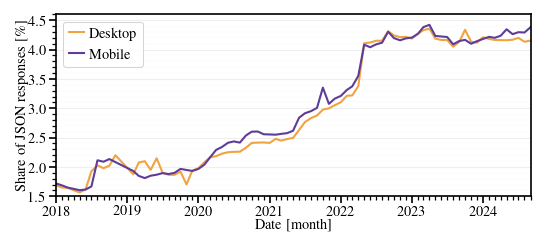

In [6]:
SLIDE_VERSION = False                   # Set to True for styling for slide set

matplotlib.pyplot.clf()

if SLIDE_VERSION:
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullslide.mplstyle")
    matplotlib.use("pgf")
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0], matplotlib.rcParams["figure.figsize"][1] * 1.5
else:
    # matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_acm.mplstyle")
    # matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth.mplstyle")
    #matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_fullwidth_acmsmall.mplstyle")
    matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_ieeetran.mplstyle")
    matplotlib.use("inline")
    #matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0] * 1.18, matplotlib.rcParams["figure.figsize"][1] * 1.5
    #matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0] * 1.17, matplotlib.rcParams["figure.figsize"][1] * 5 / 8
    matplotlib.rcParams["figure.figsize"] = matplotlib.rcParams["figure.figsize"][0], matplotlib.rcParams["figure.figsize"][1] * 5 / 8
matplotlib.pyplot.rc('axes', prop_cycle=matplotlib.pyplot.cycler(color=["#f1a340", "#5e3c99"]))

COLORS={
    "Desktop": "C0",
    "Mobile": "C1",
}
ALPHAS={
    "Desktop": 0.3,
    "Mobile": 0.1,
}

lf = polars.concat(
    polars.scan_csv(csv)
    for csv in [
        INTRODUCTION_DIR / "input_datasets" / "bq-results-20240926-131645-1727356734135.csv",
        INTRODUCTION_DIR / "input_datasets" / "bq-results-20240930-143032-1727706865287.csv",
    ]
).with_columns(
    client=polars.col("table_suffix").str.split("_").list.last().str.to_titlecase(),
    timestamp=polars.col("table_suffix").str.to_date("%y_%m_%d_", exact=False),
).select(polars.exclude("table_suffix"))

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

for client in ["Desktop", "Mobile"]:
    df = lf.filter(
        polars.col("client") == client
    ).sort("timestamp").select(
        ["timestamp", "percent_json_requests"]
    ).interpolate().collect()
    ax.plot(df["timestamp"], df["percent_json_requests"], color=COLORS[client], label=client)

ax.set_xlabel("Date [month]")
ax.set_xlim((df["timestamp"].min(), df["timestamp"].max()))
ax.set_xticks(
    polars.date_range(
        df["timestamp"].min() + dateutil.relativedelta.relativedelta(month=1, day=1),
        df["timestamp"].max(),
        "1y",
        eager=True,
    )
)
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(matplotlib.dates.MonthLocator())

ax.set_ylabel("Share of JSON responses [\\%]")
ax.set_ylim((0.015, 0.046))
ax.set_yticks(numpy.arange(0.015, 0.048, 0.005))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y * 100:0.1f}$"))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.001))

matplotlib.pyplot.grid(axis="y", alpha=0.2, which="minor", linewidth=0.1)
matplotlib.pyplot.grid(axis="y", alpha=0.2, which="major", linewidth=0.5)

ax.legend()

filepath = INTRODUCTION_DIR / "plots" / "http-archive-json-request-ratio.pdf"
IPython.display.display(IPython.display.Markdown(f"### [JSON Request Ratio]({str(filepath.relative_to(pathlib.Path.cwd()))})"))
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()
matplotlib.pyplot.close(fig)

## Response Length vs. Request/Response time

See [`07_discussion.ipynb`](./07_discussion.ipynb).

## Ratio of compressed JSON responses

In [7]:
list_code(INTRODUCTION_DIR / "input_datasets" / "bq-results-20240927-095716-1727431075335.sql")

SELECT
  resp_content_encoding, mimeType, COUNT(0) AS count
FROM
  httparchive.summary_requests.2024_09_01_desktop
GROUP BY
  resp_content_encoding,
  mimeType

In [8]:
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

compr_enc = ['br', 'compress', 'dcb', 'dcz', 'deflate', 'gzip', 'identity', 'pack200-gzip', 'x-compress', 'x-gzip', 'zstd']

lf = polars.scan_csv(
    INTRODUCTION_DIR / "input_datasets" / "bq-results-20240927-095716-1727431075335.csv"
).with_columns(
    compression_encoding=polars.col("resp_content_encoding").str.split(",").list.eval(
        polars.when(
            polars.element().str.to_lowercase().str.strip_chars().is_in(compr_enc)
        ).then(
            polars.element().str.to_lowercase().str.strip_chars()
        )
    ).list.drop_nulls(),
    media_type=polars.when(
        polars.col("mimeType").str.to_lowercase().str.contains("json")
    ).then(
        polars.lit("JSON")
    ).otherwise(
        polars.when(
            polars.col("mimeType").str.to_lowercase().str.contains("cbor")
        ).then(
            polars.lit("CBOR")
        ).otherwise(
            polars.lit("Other")
        )
    ),
).with_columns(
    compression_encoding=polars.when(
        polars.col("compression_encoding").list.len() > 0
    ).then(polars.col("compression_encoding"))
)

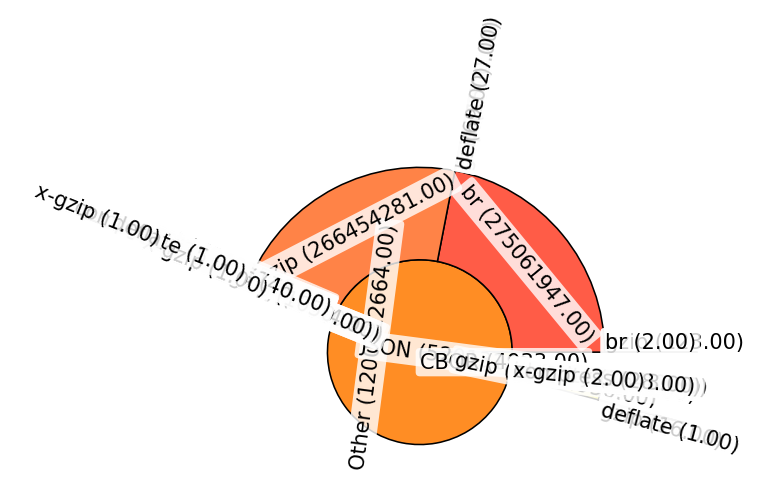

In [9]:
sunburst_df = lf.with_columns(
    sunburst=polars.concat_str(
        [
            polars.col("media_type"),
            polars.col("compression_encoding").list.join("/"),
        ],
        separator="/",
        ignore_nulls=True,
    )
).group_by("sunburst").agg(
    polars.col("count").sum()
).sort("sunburst").collect()

data = sunburst.stringvalues_to_pv(
    {d["sunburst"]: d["count"] for d in sunburst_df.to_dicts()}
)

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
sbp = sunburst.SunburstPlot(data, ax, label_minimal_angle=0)
sbp.plot(setup_axes=True)
matplotlib.pyplot.show()
matplotlib.pyplot.close(fig)

<Figure size 640x480 with 0 Axes>

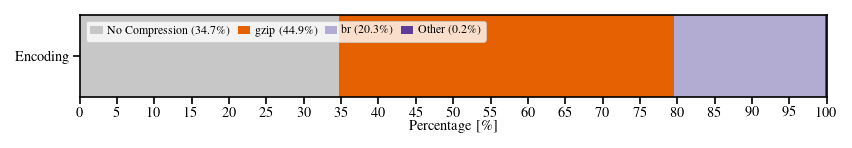

In [10]:
matplotlib.pyplot.clf()
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = ((matplotlib.rcParams["figure.figsize"][0] * 9) / 10, (matplotlib.rcParams["figure.figsize"][0] * 1) / 10)

COLORS = {
    "No Compression": "#c7c7c7",
    "gzip": "#e66101",
    "br": "#b2abd2",
    "Other": "#5e3c99",
}

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

df = lf.filter(
    polars.col("media_type") == "JSON"
).with_columns(
    compression=polars.when(
        polars.col("compression_encoding").is_null()
    ).then(polars.lit("No Compression")).otherwise(
        polars.col("compression_encoding").list.eval(
            polars.element().str.strip_chars()
        ).list.join("+")
    )
).group_by("compression").agg(
    polars.col("count").sum()
).with_columns(
    share=polars.col("count") / polars.col("count").sum()
).with_columns(
    compression=polars.when(polars.col("share") < 0.01).then(
        polars.lit("Other")
    ).otherwise(
        polars.col("compression")
    )
).group_by("compression").agg(
    polars.col("count").sum(),
    polars.col("share").sum(),
).with_columns(
    compression_index=polars.col("compression").map_elements(
        lambda x: [
            "No Compression",
            "gzip",
            "br",
            "zstd",
            "deflate",
            "x-gzip"
            "compress",
            "dcb",
            "dcz",
            "identity",
            "pack200-gzip",
            "x-compress",
            "Other",
        ].index(x),
        return_dtype=polars.UInt8,
    )
).sort("compression_index").with_columns(
    bottom=polars.col("share").cum_sum() - polars.col("share")
).select(
    ["compression", "share", "bottom"]
).collect()

df

for compression, share, bottom in df.iter_rows():
    ax.barh(0, share, left=bottom, color=COLORS[compression], height=1, label=fr"{compression} ({share * 100:.1f}\%)")

ax.legend(
    loc="upper left",
    ncol=4,
)

ax.set_yticks([0], [r"Encoding"])
ax.set_ylim((-0.5, 0.5))
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y * 100:0.0f}$"))
ax.set_xlabel(r"Percentage [\%]")
ax.set_xticks(numpy.arange(0, 1.1, 0.05))
ax.set_xlim((0, 1))

matplotlib.pyplot.show()
matplotlib.pyplot.close(fig)

## Byte size ratio of JSONs

In [11]:
list_code(INTRODUCTION_DIR / "input_datasets" / "bquxjob_ad95136_19440e1719e.sql")

SELECT 
t1.table_name as table_suffix,
total_requests,
total_json_requests,
total_json_requests/total_requests as percent_json_requests,
FROM (SELECT
  _TABLE_SUFFIX as table_name,
  SUM(respSize) total_json_requests,
FROM
  `httparchive.summary_requests.2024*`
WHERE
  LOWER(mimeType) LIKE "%json%" AND _TABLE_SUFFIX LIKE '%01_desktop' AND _TABLE_SUFFIX BETWEEN '_00' AND '_10'
GROUP BY table_name
) t1 
JOIN (SELECT
  _TABLE_SUFFIX as table_name,
  SUM(respSize) total_requests,
FROM
  `httparchive.summary_requests.2024*`
WHERE
  _TABLE_SUFFIX LIKE '%01_desktop' AND _TABLE_SUFFIX BETWEEN '_00' AND '_10'
GROUP BY table_name
) t2 ON t1.table_name = t2.table_name
ORDER BY table_suffix

In [12]:
polars.read_csv(
    INTRODUCTION_DIR / "input_datasets" / "bquxjob_ad95136_19440e1719e.csv"
).rename({"table_suffix": "date"}).with_columns(
    polars.col("percent_json_requests") * 100,
    polars.col("date").str.to_date("_%m_%d_desktop"),
).with_columns(
    date=polars.date(
        2024,
        polars.col("date").dt.month(),
        polars.col("date").dt.day(),
    )
)

date,total_requests,total_json_requests,percent_json_requests
date,i64,i64,f64
2024-01-01,53120150426223,271728609870,0.511536
2024-02-01,59821490789903,304913951529,0.509706
2024-03-01,61381997561231,316903625472,0.516281
2024-04-01,61901558657317,320177908222,0.517237
2024-05-01,62074900978116,322083783130,0.518863
2024-06-01,62043374690292,413512197406,0.666489
2024-07-01,61521917641843,381390669101,0.619926
2024-08-01,59364894870456,368745222930,0.62115
2024-09-01,59978412408858,369189063379,0.615537
